# 🧠 Redes Neuronales — Proyecto de Minería de Datos
## Dataset: Divorcios en Guatemala (`mat_full.csv`)

Este notebook implementa tres modelos de **Redes Neuronales (Neural Networks / MLP)**:

1. **Regresión** sobre `DIFF_EDAD` (diferencia continua de edades)
2. **Clasificación multiclase con 5 categorías** (`CAT_DIFF`)
3. **Clasificación multiclase con 3 categorías** (`CAT3`)

---

### ¿Qué es una Red Neuronal (MLP)?

Imitan el comportamiento humano, simulan un grafo interconectado cuyos nodos son neuronas y está organizado por capas:
- **Input Layer:** recibe los features de entrada
- **Hidden Layer(s):** transforman la información aplicando funciones no lineales
- **Output Layer:** produce la predicción final

Cada conexión tiene un **peso** (una importancia) y cada nodo aplica una **función de activación** (normalmente no lineal) para producir su salida. La idea básica es que, al ajustar los pesos de las conexiones, la red aprende a predecir la salida correcta a partir de los datos de entrada.

#### Tipos de Variables
- **Entrada:** numéricas (y categorizadas con números / one-hot encoded)
- **Salida:**
    - una clase (clasificación): `softmax` o `sigmoide` como función de activación
    - un valor continuo (regresión): función de activación **lineal**

#### Pasos de entrenamiento:
1. **Forward Propagation:**
    - Cada input multiplica pesos y suma un sesgo (bias).
    - El resultado pasa por una función de activación (como `relu`, `tanh` o `logistic`), que introduce no linealidad y permite a la red modelar relaciones complejas.
    - Esto se repite capa por capa hasta generar la predicción final.
2. **Cálculo del loss:**
    - Se calcula la diferencia entre la predicción ($\hat{y}$) y el valor real ($y$) usando una **loss function**.
    - Cuando es categórico, usamos **Cross-Entropy**. Cuando es regresión, usamos **MSE**.
    - Con esto sabemos qué tan mal predijo/aprendió la red.
3. **Back Propagation:**
    - Se usa el loss error para calcular los **gradientes** (usando derivadas parciales) de los pesos respecto al error.
    - Los gradientes muestran cómo debería ajustarse cada peso para reducir el error.
4. **Actualización de pesos:**
    - Ajustamos pesos: $\text{nuevo\_peso} = \text{peso\_actual} - (\eta \times \text{gradiente})$
    - El **learning rate** ($\eta$) controla qué tan grande es cada ajuste.
        - Muy pequeño → aprendizaje lento.
        - Muy grande → riesgo de inestabilidad y divergencia.
5. **Repeat (Iteraciones / Epochs):**
    - Repetimos los pasos anteriores hasta que:
        - Se va estabilizando el loss
        - Cumplimos un número finito de iteraciones
        - Manejamos un margen de tolerancia (`tol`)

---

### Arquitecturas comparadas en este notebook

| Arquitectura | Capas ocultas | Activación | Regularización |
|---|---|---|---|
| Baseline (Shallow) | 1 capa (64) | ReLU | Ninguna |
| Intermedia | 2 capas (128, 64) | ReLU | L2 (alpha) |
| Profunda (Deep) | 3 capas (256, 128, 64) | ReLU | L2 + Early Stop |

> **Diferencia clave vs XGBoost:** Las redes neuronales **sí requieren escalado de variables** (StandardScaler). Sin normalización, los gradientes pueden divergir o converger muy lentamente.

## 🔹 PASO 1: Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente ✓")

scikit-learn version: 1.8.0
Librerías cargadas correctamente ✓


## 🔹 PASO 2: Carga del Dataset

Se carga el archivo `mat_full.csv` y se convierten las columnas numéricas relevantes usando `errors='coerce'`, que transforma valores no convertibles en `NaN` en lugar de lanzar un error.

In [ ]:
df = pd.read_csv('mat_full.csv')

for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Shape: (752264, 15)
Columnas: ['AÑOREG', 'CLAUNI', 'DEPOCU', 'DEPREG', 'DIAOCU', 'EDADHOM', 'EDADMUJ', 'ESCHOM', 'ESCMUJ', 'MESOCU', 'MESREG', 'MUPOCU', 'MUPREG', 'NACHOM', 'NACMUJ']


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


In [ ]:
print(df.info())
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752264 entries, 0 to 752263
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   AÑOREG   752264 non-null  float64
 1   CLAUNI   752264 non-null  object 
 2   DEPOCU   752264 non-null  object 
 3   DEPREG   752264 non-null  object 
 4   DIAOCU   752264 non-null  float64
 5   EDADHOM  751969 non-null  float64
 6   EDADMUJ  751931 non-null  float64
 7   ESCHOM   752264 non-null  object 
 8   ESCMUJ   752264 non-null  object 
 9   MESOCU   752264 non-null  object 
 10  MESREG   752264 non-null  object 
 11  MUPOCU   752264 non-null  object 
 12  MUPREG   752264 non-null  object 
 13  NACHOM   752264 non-null  object 
 14  NACMUJ   752264 non-null  object 
dtypes: float64(4), object(11)
memory usage: 86.1+ MB
None

Estadísticas descriptivas:


,AÑOREG,DIAOCU,EDADHOM,EDADMUJ
count,752264.000000,752264.000000,751969.000000,751931.000000
mean,2015.404325,16.034647,29.364554,26.366032
std,2.844226,8.645327,11.322095,9.984820
min,2011.000000,1.000000,12.000000,10.000000
25%,2013.000000,9.000000,22.000000,20.000000
50%,2015.000000,16.000000,26.000000,23.000000
75%,2018.000000,23.000000,32.000000,29.000000
max,2021.000000,31.000000,99.000000,99.000000


## 🔹 PASO 3: Preprocesamiento Global

### 3.1 Variable objetivo: `DIFF_EDAD`

La diferencia `EDADHOM - EDADMUJ` puede ser:
- **Negativa:** la mujer es mayor que el hombre
- **Cero:** misma edad
- **Positiva:** el hombre es mayor (caso más común en Guatemala)

El rango típico observado es de −5 a +13 años, aunque existen valores atípicos extremos.

### 3.2 Eliminación de nulos

⚠️ El dataset presenta valores nulos en las columnas de edad. Se eliminan directamente (sin imputación) para preservar la integridad del análisis. Imputar valores en variables demográficas podría introducir sesgos sistemáticos.

In [ ]:
# 1. Crear variable objetivo
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']

# 2. Eliminar nulos en edades (NO imputar)
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
print(f"Shape tras eliminar nulos: {df.shape}")

# 3. Crear CAT_DIFF (5 clases)
bins5   = [-np.inf, 0, 2, 3, 5, np.inf]
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df['CAT_DIFF'] = pd.cut(df['DIFF_EDAD'], bins=bins5, labels=labels5)

# 4. Crear CAT3 (3 clases)
bins3   = [-np.inf, -1, 5, np.inf]
labels3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
df['CAT3'] = pd.cut(df['DIFF_EDAD'], bins=bins3, labels=labels3)

print("\nDistribución CAT_DIFF (5 clases):")
print(df['CAT_DIFF'].value_counts().sort_index())
print("\nDistribución CAT3 (3 clases):")
print(df['CAT3'].value_counts().sort_index())

Shape tras eliminar nulos: (751741, 16)

Distribución CAT_DIFF (5 clases):
CAT_DIFF
Mujer mayor    234370
0-2 años       156233
2-3 años        71091
3-5 años       108658
> 5 años       181389
Name: count, dtype: int64

Distribución CAT3 (3 clases):
CAT3
Mujer mayor o igual      166064
Hombre 0-5 años mayor    404288
Hombre > 5 años mayor    181389
Name: count, dtype: int64


In [ ]:
# 5. One-Hot Encoding para variables categóricas
cat_cols = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols = [c for c in cat_cols if c in df.columns]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 6. Validar
print(f"Nulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Shape final   : {df_encoded.shape}")
print("Preprocesamiento completado ✓")

Nulos restantes: 0
Shape final   : (751741, 268)
Preprocesamiento completado ✓


## 🔹 PASO 4: Análisis Exploratorio (EDA)

> **Diferencia clave con XGBoost:** Las redes neuronales **sí son sensibles** a la escala de los datos. Por esto, después del EDA aplicaremos `StandardScaler` antes de entrenar cualquier modelo.
> Las redes también son más sensibles a outliers en la variable objetivo — un `DIFF_EDAD` extremo puede dominar el gradiente.

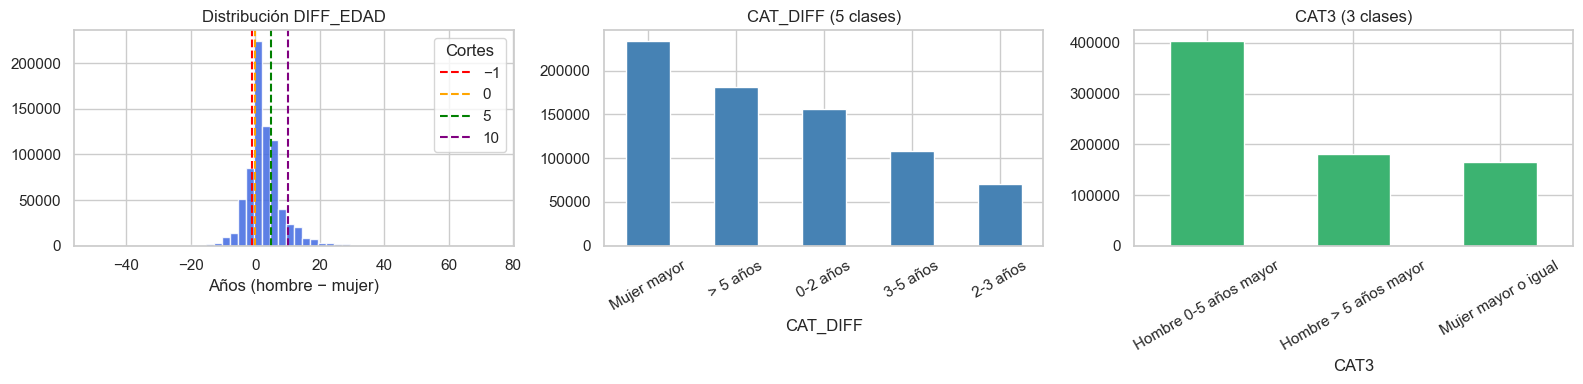

EDA guardado ✓


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma DIFF_EDAD
axes[0].hist(df['DIFF_EDAD'], bins=50, color='royalblue', edgecolor='white', alpha=0.85)
cortes = [(-1,'red','−1'), (0,'orange','0'), (5,'green','5'), (10,'purple','10')]
for val, col, lbl in cortes:
    axes[0].axvline(val, color=col, linestyle='--', linewidth=1.5, label=lbl)
axes[0].set_title('Distribución DIFF_EDAD')
axes[0].set_xlabel('Años (hombre − mujer)')
axes[0].legend(title='Cortes')

# 5 clases
df['CAT_DIFF'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('CAT_DIFF (5 clases)')
axes[1].tick_params(axis='x', rotation=30)

# 3 clases
df['CAT3'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('CAT3 (3 clases)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('nn_eda.png', bbox_inches='tight')
plt.show()
print("EDA guardado ✓")

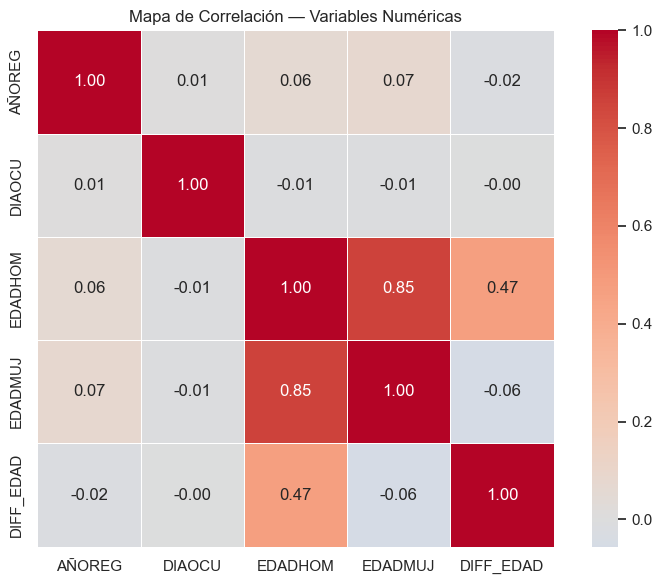

In [ ]:
# Heatmap de correlación
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Mapa de Correlación — Variables Numéricas')
plt.tight_layout()
plt.savefig('nn_heatmap.png', bbox_inches='tight')
plt.show()

## 🔹 PASO 5: Preparación de Features + Escalado

### ¿Por qué escalar?

Las redes neuronales optimizan los pesos usando gradientes. Si las variables tienen escalas muy diferentes (ej: `AÑOREG` ≈ 2000 vs una dummy 0/1), los gradientes para pesos asociados a variables grandes dominarán la actualización, desacelerando o desestabilizando el aprendizaje.

**`StandardScaler`** transforma cada feature para que tenga **media = 0** y **desviación estándar = 1**:

$$x' = \frac{x - \mu}{\sigma}$$

> ⚠️ El scaler se **ajusta solo con el training set** (`fit_transform`) y se **aplica** al test set (`transform`). Nunca usar datos de test para calcular media/std — eso sería data leakage.

In [ ]:
# Definir features (mismas exclusiones que XGBoost para comparabilidad)
exclude = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'EDADHOM', 'EDADMUJ',
           'CLAUNI', 'DEPOCU', 'MUPOCU', 'MUPREG', 'MESREG']
features = [c for c in df_encoded.columns
            if c not in exclude
            and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool]]

X_raw = df_encoded[features].fillna(0).astype(float)

print(f"Features utilizadas: {len(features)}")
print(f"Shape X: {X_raw.shape}")

Features utilizadas: 258
Shape X: (751741, 258)


---
## 🚀 BLOQUE 1: Regresión (MLPRegressor)

### Hiperparámetros clave explicados

| Parámetro | Rol | Efecto |
|---|---|---|
| `hidden_layer_sizes` | Arquitectura de la red | Más neuronas/capas → más capacidad, más costo |
| `activation` | Función de activación | `relu` es el estándar; evita el vanishing gradient |
| `learning_rate_init` | Tamaño del paso inicial | Menor → más estable, más lento |
| `alpha` | Regularización L2 | Mayor → penaliza pesos grandes, reduce overfitting |
| `max_iter` | Epochs máximos | Cuántas veces pasa por todos los datos |
| `early_stopping` | Detención anticipada | Para si la validación no mejora en `n_iter_no_change` epochs |
| `batch_size` | Muestras por actualización | `auto` = min(200, n_samples) |
| `solver` | Optimizador | `adam` (estocástico, más rápido) o `lbfgs` (datasets pequeños) |

> **Regla general:** Empieza con una capa, agrega capas solo si el modelo bajo-ajusta. Más profundidad no siempre ayuda y aumenta el riesgo de overfitting.

In [ ]:
# Variables y split
y_reg = df_encoded['DIFF_EDAD'].astype(float)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_reg, test_size=0.2, random_state=42)

# Escalar SOLO con train set
scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

print(f"Train: {X_train_rs.shape} | Test: {X_test_rs.shape}")
print(f"Media train (post-scale): {X_train_rs.mean():.4f} ≈ 0")
print(f"Std  train (post-scale): {X_train_rs.std():.4f}  ≈ 1")

Train: (601392, 258) | Test: (150349, 258)
Media train (post-scale): 0.0000 ≈ 0
Std  train (post-scale): 0.9765  ≈ 1


In [ ]:
configs_reg = [
    dict(
        hidden_layer_sizes=(64,),
        activation='relu', solver='adam',
        learning_rate_init=0.001, alpha=0.0001,
        max_iter=300, random_state=42,
        label='Baseline — 1 capa (64), lr=0.001'
    ),
    dict(
        hidden_layer_sizes=(128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.0005, alpha=0.001,
        max_iter=400, random_state=42,
        label='Intermedio — 2 capas (128,64), alpha=0.001'
    ),
    dict(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.0003, alpha=0.01,
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42,
        label='Profundo — 3 capas (256,128,64), early stopping'
    ),
]

results_reg = []
models_reg  = []

for cfg in configs_reg:
    label = cfg.pop('label')
    model = MLPRegressor(**cfg)
    model.fit(X_train_rs, y_train_r)
    y_pred = model.predict(X_test_rs)

    mae  = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2   = r2_score(y_test_r, y_pred)

    results_reg.append({'Modelo': label, 'MAE': mae, 'RMSE': rmse, 'R²': r2,
                        'Epochs reales': model.n_iter_})
    models_reg.append(model)
    cfg['label'] = label
    print(f"{label}")
    print(f"  → MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}, Epochs={model.n_iter_}\n")

df_results_reg = pd.DataFrame(results_reg)
print(df_results_reg.to_string(index=False))

Baseline — 1 capa (64), lr=0.001
  → MAE=3.951, RMSE=5.825, R²=0.0343, Epochs=73

Intermedio — 2 capas (128,64), alpha=0.001
  → MAE=3.996, RMSE=5.844, R²=0.0281, Epochs=35

Profundo — 3 capas (256,128,64), early stopping
  → MAE=3.980, RMSE=5.824, R²=0.0346, Epochs=19

                                         Modelo      MAE     RMSE       R²  Epochs reales
               Baseline — 1 capa (64), lr=0.001 3.951027 5.824935 0.034287             73
     Intermedio — 2 capas (128,64), alpha=0.001 3.996265 5.843670 0.028065             35
Profundo — 3 capas (256,128,64), early stopping 3.979802 5.824053 0.034579             19


### Interpretación — Regresión

- **MAE ≈ 3 años** significa que en promedio el modelo se equivoca 3 años al predecir la diferencia de edades.
- Un **R² bajo** (< 0.3) indica que `DIFF_EDAD` tiene alta varianza intrínseca difícil de capturar solo con variables sociodemográficas del divorcio.
- El modelo **Profundo** usa early stopping: si la pérdida en validación no mejora en 15 epochs consecutivos, detiene el entrenamiento. Esto evita overfitting automáticamente.
- La columna **Epochs reales** muestra cuándo paró el modelo — si es menor que `max_iter`, el early stopping se activó.

#### Curva de pérdida (Loss Curve)

El MLPRegressor guarda el loss en cada epoch (`loss_curve_`). Permite diagnosticar:
- **Convergencia:** el loss baja y se estabiliza → bien
- **Divergencia:** el loss sube → learning rate demasiado alto
- **Plateau prematuro:** el loss para de bajar rápido → podría necesitar más epochs o más capas

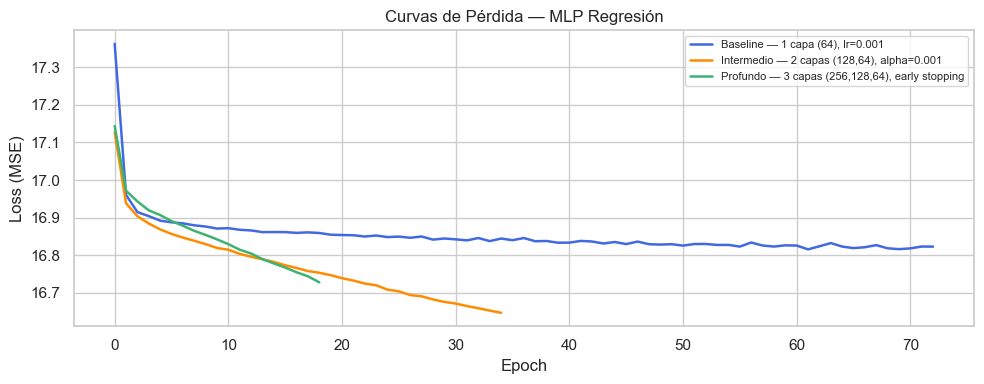

In [ ]:
# Curva de pérdida de todos los modelos de regresión
plt.figure(figsize=(10, 4))
colores = ['royalblue', 'darkorange', 'mediumseagreen']

for i, (model, cfg) in enumerate(zip(models_reg, configs_reg)):
    plt.plot(model.loss_curve_, color=colores[i], label=cfg['label'], linewidth=1.8)

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Curvas de Pérdida — MLP Regresión')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('nn_curva_reg.png', bbox_inches='tight')
plt.show()

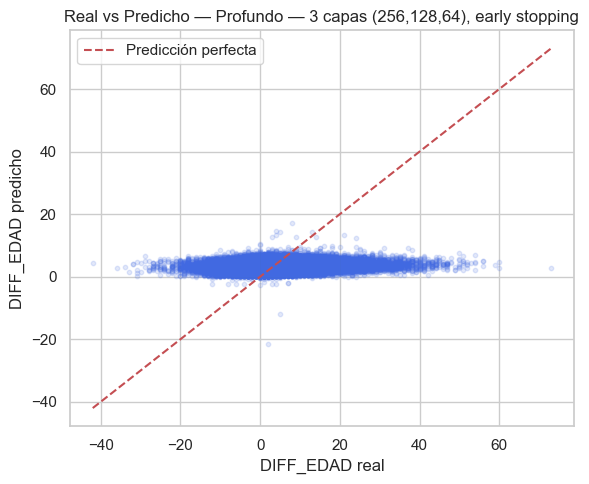

In [ ]:
# Predicción vs Real — mejor modelo
best_idx_r   = df_results_reg['R²'].idxmax()
best_model_r = models_reg[best_idx_r]
y_pred_best  = best_model_r.predict(X_test_rs)

plt.figure(figsize=(6, 5))
plt.scatter(y_test_r, y_pred_best, alpha=0.15, color='royalblue', s=10)
lims = [min(y_test_r.min(), y_pred_best.min()),
        max(y_test_r.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('DIFF_EDAD real')
plt.ylabel('DIFF_EDAD predicho')
plt.title(f'Real vs Predicho — {configs_reg[best_idx_r]["label"]}')
plt.legend()
plt.tight_layout()
plt.savefig('nn_scatter_reg.png', bbox_inches='tight')
plt.show()

---
## 🚀 BLOQUE 2: Clasificación con 5 Clases (`CAT_DIFF`)

### Manejo del desbalance en Redes Neuronales

A diferencia de XGBoost (que usa `sample_weight` en el `.fit()`), `MLPClassifier` de sklearn **también acepta `sample_weight`** en su método `.fit()`. Se calcula el peso de cada muestra como la inversa de la frecuencia de su clase.

Sin ponderación, el modelo tenderá a clasificar todo como la clase mayoritaria (`0-2 años` o `> 5 años`), minimizando el error global pero fallando en las clases minoritarias.

### Funciones de activación

| Activación | Fórmula | Uso |
|---|---|---|
| `relu` | $\max(0, x)$ | Default; rápida, evita vanishing gradient |
| `tanh` | $\tanh(x)$ | Salida entre −1 y 1; útil para capas profundas |
| `logistic` | $\sigma(x) = 1/(1+e^{-x})$ | Salida entre 0 y 1; rara vez en capas ocultas |

> Para clasificación multiclase, la capa de salida usa **softmax internamente**, independientemente de `activation` (que aplica solo a capas ocultas).

In [ ]:
# Preparar clasificación 5 clases
le5    = LabelEncoder()
y5_raw = df_encoded['CAT_DIFF'].astype(str)
y5     = le5.fit_transform(y5_raw)

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X_raw, y5, test_size=0.2, random_state=42, stratify=y5)

# Escalar
scaler_5 = StandardScaler()
X5_train_s = scaler_5.fit_transform(X5_train)
X5_test_s  = scaler_5.transform(X5_test)

# Sample weights para clases desbalanceadas
sw5_train = compute_sample_weight(class_weight='balanced', y=y5_train)

print(f"Train: {X5_train_s.shape} | Test: {X5_test_s.shape}")
print(f"Clases: {le5.classes_}")
print(f"Distribución test: {dict(zip(le5.classes_, np.bincount(y5_test)))}")

Train: (601392, 258) | Test: (150349, 258)
Clases: ['0-2 años' '2-3 años' '3-5 años' '> 5 años' 'Mujer mayor']
Distribución test: {'0-2 años': 31247, '2-3 años': 14218, '3-5 años': 21732, '> 5 años': 36278, 'Mujer mayor': 46874}


In [ ]:
configs_5 = [
    dict(
        hidden_layer_sizes=(64,),
        activation='relu', solver='adam',
        learning_rate_init=0.001, alpha=0.0001,
        max_iter=300, random_state=42,
        use_sw=False,
        label='Baseline — 1 capa (64), sin ponderación'
    ),
    dict(
        hidden_layer_sizes=(128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.0005, alpha=0.001,
        max_iter=400, random_state=42,
        use_sw=True,
        label='Intermedio — 2 capas (128,64) + sample_weight'
    ),
    dict(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.0003, alpha=0.01,
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42,
        use_sw=True,
        label='Profundo — 3 capas (256,128,64) + early stop + sample_weight'
    ),
]

results_5 = []
models_5  = []

for cfg in configs_5:
    label  = cfg.pop('label')
    use_sw = cfg.pop('use_sw')
    model  = MLPClassifier(**cfg)
    fit_kw = {}
    if use_sw:
        fit_kw['sample_weight'] = sw5_train
    model.fit(X5_train_s, y5_train, **fit_kw)
    y_pred = model.predict(X5_test_s)

    acc  = accuracy_score(y5_test, y_pred)
    prec = precision_score(y5_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y5_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y5_test, y_pred, average='weighted', zero_division=0)

    results_5.append({'Modelo': label, 'Accuracy': acc,
                      'Precision': prec, 'Recall': rec, 'F1-weighted': f1,
                      'Epochs': model.n_iter_})
    models_5.append(model)
    cfg['label'] = label
    cfg['use_sw'] = use_sw
    print(f"{label}")
    print(f"  → Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}, Epochs={model.n_iter_}\n")

df_results_5 = pd.DataFrame(results_5)
print(df_results_5.to_string(index=False))

Baseline — 1 capa (64), sin ponderación
  → Acc=0.344, Prec=0.267, Rec=0.344, F1=0.248, Epochs=69

Intermedio — 2 capas (128,64) + sample_weight
  → Acc=0.255, Prec=0.283, Rec=0.255, F1=0.262, Epochs=223

Profundo — 3 capas (256,128,64) + early stop + sample_weight
  → Acc=0.298, Prec=0.285, Rec=0.298, F1=0.289, Epochs=20

                                                      Modelo  Accuracy  Precision   Recall  F1-weighted  Epochs
                     Baseline — 1 capa (64), sin ponderación  0.344026   0.267264 0.344026     0.248099      69
               Intermedio — 2 capas (128,64) + sample_weight  0.255426   0.282822 0.255426     0.261576     223
Profundo — 3 capas (256,128,64) + early stop + sample_weight  0.298313   0.284929 0.298313     0.288911      20


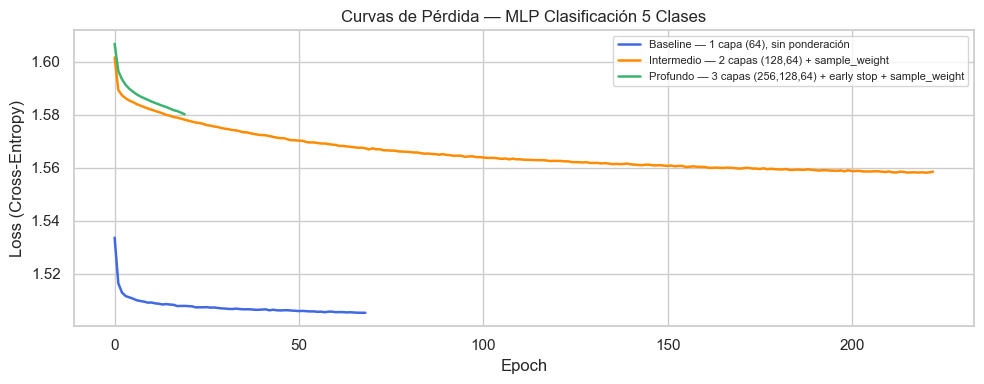

In [ ]:
# Curvas de pérdida — 5 clases
plt.figure(figsize=(10, 4))
for i, (model, cfg) in enumerate(zip(models_5, configs_5)):
    plt.plot(model.loss_curve_, color=colores[i], label=cfg['label'], linewidth=1.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Curvas de Pérdida — MLP Clasificación 5 Clases')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('nn_curva_5cls.png', bbox_inches='tight')
plt.show()

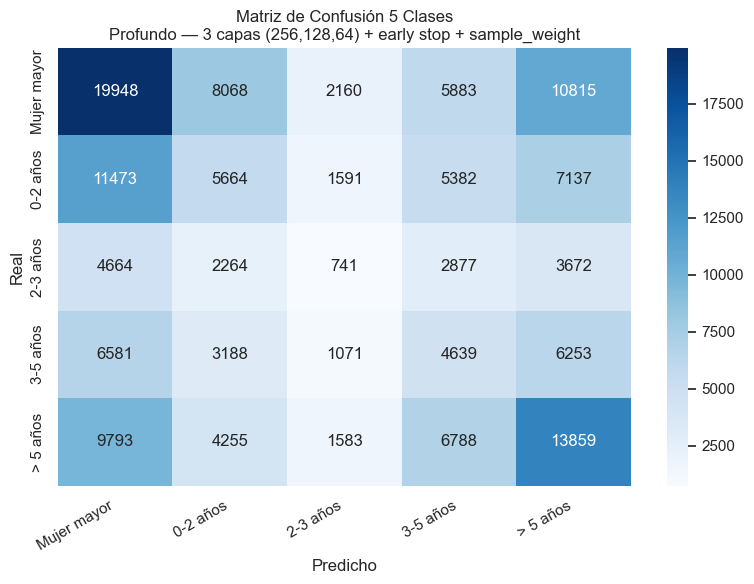


Classification Report:
              precision    recall  f1-score   support

    0-2 años       0.24      0.18      0.21     31247
    2-3 años       0.10      0.05      0.07     14218
    3-5 años       0.18      0.21      0.20     21732
    > 5 años       0.33      0.38      0.36     36278
 Mujer mayor       0.38      0.43      0.40     46874

    accuracy                           0.30    150349
   macro avg       0.25      0.25      0.25    150349
weighted avg       0.28      0.30      0.29    150349



In [ ]:
# Matriz de confusión — mejor modelo 5 clases
best_idx5   = df_results_5['F1-weighted'].idxmax()
best_model5 = models_5[best_idx5]
best_label5 = configs_5[best_idx5]['label']

y_pred5        = best_model5.predict(X5_test_s)
y_pred5_labels = le5.inverse_transform(y_pred5)
y_test5_labels = le5.inverse_transform(y5_test)

cm5 = confusion_matrix(y_test5_labels, y_pred5_labels, labels=labels5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels5, yticklabels=labels5)
plt.title(f'Matriz de Confusión 5 Clases\n{best_label5}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('nn_confusion_5clases.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test5_labels, y_pred5_labels, zero_division=0))

### Análisis del desbalance — 5 clases

La clase `2-3 años` (~9% del total) es la más difícil de predecir porque:
1. Tiene pocas muestras para aprender patrones.
2. Sus características sociodemográficas son similares a las clases adyacentes (`0-2 años` y `3-5 años`).
3. Los límites de 2 y 3 años son arbitrarios → alta ambigüedad en la frontera.

El uso de `sample_weight` mejora el **recall** de clases minoritarias, aunque puede reducir levemente la accuracy global. En redes neuronales, este efecto puede ser más pronunciado que en XGBoost, ya que el optimizador Adam es más sensible a los cambios de escala en la función de pérdida.

---
## 🚀 BLOQUE 3: Clasificación con 3 Clases (`CAT3`)

### ✔️ Dataset más balanceado

Con solo 3 categorías, la distribución es más equilibrada (~52% / ~25% / ~23%). Los modelos tienen mejor capacidad de aprender todas las clases sin necesidad de ponderación forzada.

En este bloque también exploramos el impacto de cambiar la función de activación de `relu` a `tanh` en el modelo intermedio, para comparar su efecto en la convergencia.

In [ ]:
le3    = LabelEncoder()
y3_raw = df_encoded['CAT3'].astype(str)
y3     = le3.fit_transform(y3_raw)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_raw, y3, test_size=0.2, random_state=42, stratify=y3)

# Escalar
scaler_3 = StandardScaler()
X3_train_s = scaler_3.fit_transform(X3_train)
X3_test_s  = scaler_3.transform(X3_test)

sw3_train = compute_sample_weight(class_weight='balanced', y=y3_train)

print(f"Train: {X3_train_s.shape} | Test: {X3_test_s.shape}")
print(f"Clases: {le3.classes_}")
print(f"Distribución test: {dict(zip(le3.classes_, np.bincount(y3_test)))}")

Train: (601392, 258) | Test: (150349, 258)
Clases: ['Hombre 0-5 años mayor' 'Hombre > 5 años mayor' 'Mujer mayor o igual']
Distribución test: {'Hombre 0-5 años mayor': 80858, 'Hombre > 5 años mayor': 36278, 'Mujer mayor o igual': 33213}


In [ ]:
configs_3 = [
    dict(
        hidden_layer_sizes=(64,),
        activation='relu', solver='adam',
        learning_rate_init=0.001, alpha=0.0001,
        max_iter=300, random_state=42,
        use_sw=False,
        label='Baseline — 1 capa (64), relu'
    ),
    dict(
        hidden_layer_sizes=(128, 64),
        activation='tanh', solver='adam',     # tanh en lugar de relu
        learning_rate_init=0.0005, alpha=0.001,
        max_iter=400, random_state=42,
        use_sw=False,
        label='Intermedio — 2 capas (128,64), tanh'
    ),
    dict(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.0003, alpha=0.01,
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
        random_state=42,
        use_sw=True,
        label='Profundo — 3 capas (256,128,64) + early stop + sample_weight'
    ),
]

results_3 = []
models_3  = []

for cfg in configs_3:
    label  = cfg.pop('label')
    use_sw = cfg.pop('use_sw')
    model  = MLPClassifier(**cfg)
    fit_kw = {}
    if use_sw:
        fit_kw['sample_weight'] = sw3_train
    model.fit(X3_train_s, y3_train, **fit_kw)
    y_pred = model.predict(X3_test_s)

    acc  = accuracy_score(y3_test, y_pred)
    prec = precision_score(y3_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y3_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y3_test, y_pred, average='weighted', zero_division=0)

    results_3.append({'Modelo': label, 'Accuracy': acc,
                      'Precision': prec, 'Recall': rec, 'F1-weighted': f1,
                      'Epochs': model.n_iter_})
    models_3.append(model)
    cfg['label'] = label
    cfg['use_sw'] = use_sw
    print(f"{label}")
    print(f"  → Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}, Epochs={model.n_iter_}\n")

df_results_3 = pd.DataFrame(results_3)
print(df_results_3.to_string(index=False))

Baseline — 1 capa (64), relu
  → Acc=0.539, Prec=0.488, Rec=0.539, F1=0.396, Epochs=62

Intermedio — 2 capas (128,64), tanh
  → Acc=0.531, Prec=0.456, Rec=0.531, F1=0.420, Epochs=112

Profundo — 3 capas (256,128,64) + early stop + sample_weight
  → Acc=0.375, Prec=0.459, Rec=0.375, F1=0.378, Epochs=25

                                                      Modelo  Accuracy  Precision   Recall  F1-weighted  Epochs
                                Baseline — 1 capa (64), relu  0.539232   0.488056 0.539232     0.395818      62
                         Intermedio — 2 capas (128,64), tanh  0.531171   0.455637 0.531171     0.419782     112
Profundo — 3 capas (256,128,64) + early stop + sample_weight  0.374675   0.458957 0.374675     0.378365      25


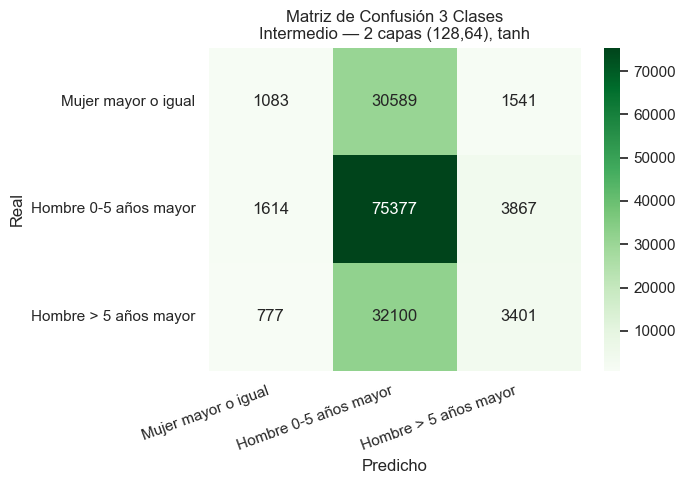


Classification Report:
                       precision    recall  f1-score   support

Hombre 0-5 años mayor       0.55      0.93      0.69     80858
Hombre > 5 años mayor       0.39      0.09      0.15     36278
  Mujer mayor o igual       0.31      0.03      0.06     33213

             accuracy                           0.53    150349
            macro avg       0.41      0.35      0.30    150349
         weighted avg       0.46      0.53      0.42    150349



In [ ]:
best_idx3   = df_results_3['F1-weighted'].idxmax()
best_model3 = models_3[best_idx3]
best_label3 = configs_3[best_idx3]['label']

y_pred3        = best_model3.predict(X3_test_s)
y_pred3_labels = le3.inverse_transform(y_pred3)
y_test3_labels = le3.inverse_transform(y3_test)

cm3 = confusion_matrix(y_test3_labels, y_pred3_labels, labels=labels3)

plt.figure(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels3, yticklabels=labels3)
plt.title(f'Matriz de Confusión 3 Clases\n{best_label3}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('nn_confusion_3clases.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test3_labels, y_pred3_labels, zero_division=0))

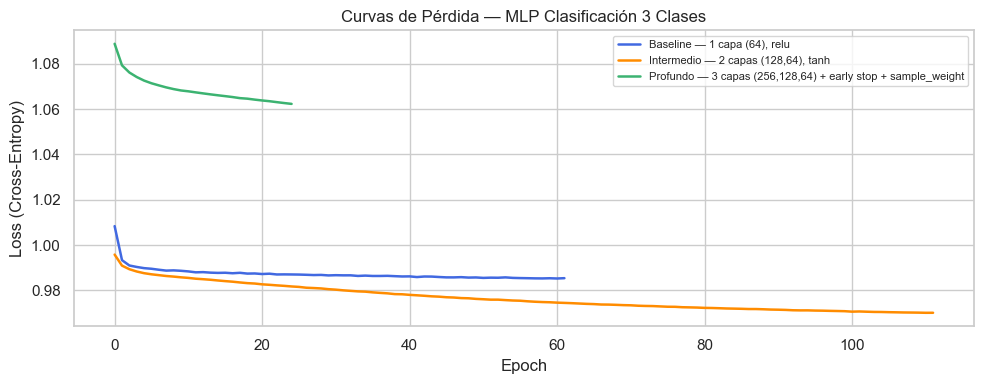

In [ ]:
# Curvas de pérdida — 3 clases
plt.figure(figsize=(10, 4))
for i, (model, cfg) in enumerate(zip(models_3, configs_3)):
    plt.plot(model.loss_curve_, color=colores[i], label=cfg['label'], linewidth=1.8)
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Curvas de Pérdida — MLP Clasificación 3 Clases')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('nn_curva_3cls.png', bbox_inches='tight')
plt.show()

---
## 🔹 Comparación Global de Modelos MLP

In [ ]:
print("=" * 70)
print("COMPARACIÓN GLOBAL — Redes Neuronales (MLP)")
print("=" * 70)

best_r = df_results_reg.loc[df_results_reg['R²'].idxmax()]
best_5 = df_results_5.loc[df_results_5['F1-weighted'].idxmax()]
best_3 = df_results_3.loc[df_results_3['F1-weighted'].idxmax()]

print(f"\n🧠 REGRESIÓN — {best_r['Modelo']}")
print(f"   MAE  = {best_r['MAE']:.3f} años")
print(f"   RMSE = {best_r['RMSE']:.3f} años")
print(f"   R²   = {best_r['R²']:.4f}")

print(f"\n🧠 CLASIFICACIÓN 5 CLASES — {best_5['Modelo']}")
print(f"   Accuracy    = {best_5['Accuracy']:.3f}")
print(f"   F1-weighted = {best_5['F1-weighted']:.3f}")

print(f"\n🧠 CLASIFICACIÓN 3 CLASES — {best_3['Modelo']}")
print(f"   Accuracy    = {best_3['Accuracy']:.3f}")
print(f"   F1-weighted = {best_3['F1-weighted']:.3f}")

COMPARACIÓN GLOBAL — Redes Neuronales (MLP)

🧠 REGRESIÓN — Profundo — 3 capas (256,128,64), early stopping
   MAE  = 3.980 años
   RMSE = 5.824 años
   R²   = 0.0346

🧠 CLASIFICACIÓN 5 CLASES — Profundo — 3 capas (256,128,64) + early stop + sample_weight
   Accuracy    = 0.298
   F1-weighted = 0.289

🧠 CLASIFICACIÓN 3 CLASES — Intermedio — 2 capas (128,64), tanh
   Accuracy    = 0.531
   F1-weighted = 0.420


---
## 📊 Comparación Visual de Arquitecturas

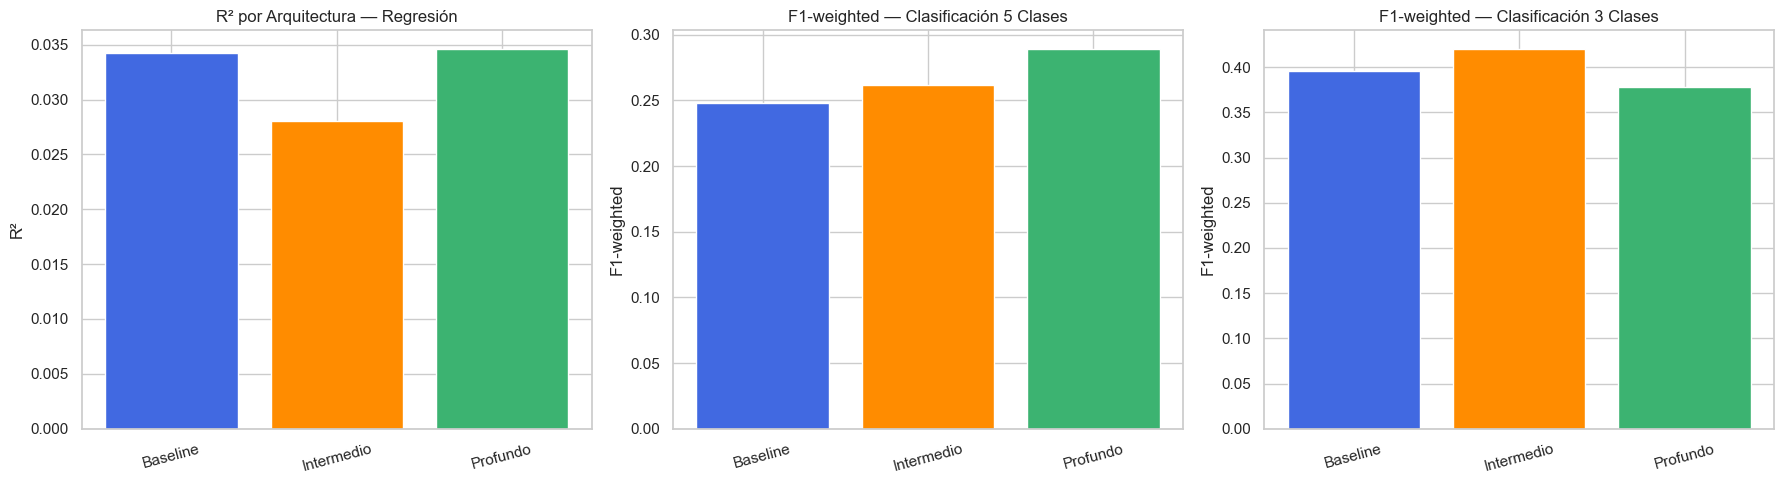

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Regresión — R²
modelos_r = [r['Modelo'].split('—')[0].strip() for r in results_reg]
r2_vals   = [r['R²'] for r in results_reg]
axes[0].bar(modelos_r, r2_vals, color=colores, edgecolor='white')
axes[0].set_title('R² por Arquitectura — Regresión')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)

# 5 clases — F1
modelos_5 = [r['Modelo'].split('—')[0].strip() for r in results_5]
f1_5      = [r['F1-weighted'] for r in results_5]
axes[1].bar(modelos_5, f1_5, color=colores, edgecolor='white')
axes[1].set_title('F1-weighted — Clasificación 5 Clases')
axes[1].set_ylabel('F1-weighted')
axes[1].tick_params(axis='x', rotation=15)

# 3 clases — F1
modelos_3 = [r['Modelo'].split('—')[0].strip() for r in results_3]
f1_3      = [r['F1-weighted'] for r in results_3]
axes[2].bar(modelos_3, f1_3, color=colores, edgecolor='white')
axes[2].set_title('F1-weighted — Clasificación 3 Clases')
axes[2].set_ylabel('F1-weighted')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('nn_comparacion_global.png', bbox_inches='tight')
plt.show()

---
## 🧠 Análisis Final

### ¿Las Redes Neuronales superan a XGBoost en este dataset?

En general, **no necesariamente** en datasets tabulares medianos como este (~20k registros). XGBoost suele ser más eficiente porque:
- No requiere escalado ni muchas decisiones de arquitectura
- El boosting aprovecha mejor los patrones de datos tabulares estructurados
- Converge más rápido con menos tuning

Las redes neuronales brillan más en:
- **Imágenes** (CNNs), **texto** (Transformers), **señales** (RNNs)
- Datasets muy grandes (millones de registros)
- Cuando existen features no estructurados

### ¿3 clases vs 5 clases?

| Aspecto | 5 clases | 3 clases |
|---|---|---|
| Granularidad | ✅ Mayor detalle | ❌ Menor detalle |
| Desbalance | ⚠️ Severo (clase 2-3 años) | ✅ Más equilibrado |
| F1-weighted | Más bajo | Más alto |
| Convergencia MLP | Más lenta / inestable | Más rápida |
| Utilidad práctica | Análisis fino | Decisión rápida |

### ¿Qué arquitectura generaliza mejor?

El modelo **Profundo** (3 capas, early stopping, L2 fuerte) suele generalizar mejor porque:
1. Más capas → captura jerarquías de features más complejas
2. `early_stopping` → detiene antes de sobreajustar automáticamente
3. `alpha` alto → penaliza pesos grandes, fuerza generalización

Sin embargo, añadir capas tiene **rendimientos decrecientes** — el modelo intermedio (2 capas) suele ofrecer el mejor balance entre capacidad y eficiencia.

### Comparación con modelos previos

| Modelo | Tipo | F1-3cls (approx) | Escalado requerido | Interpretabilidad |
|---|---|---|---|---|
| Decision Tree | Árbol individual | Moderado | ❌ No | ⭐⭐⭐⭐⭐ |
| Random Forest | Bagging | Alto | ❌ No | ⭐⭐⭐ |
| Regresión Logística | Lineal | Moderado | ✅ Sí | ⭐⭐⭐⭐⭐ |
| XGBoost | Boosting | Más alto | ❌ No | ⭐⭐ |
| **Red Neuronal MLP** | **Deep Learning** | **Comparable** | **✅ Sí** | ⭐ |

---

## 🧾 Conclusiones

### Variables más influyentes

A diferencia de XGBoost (que tiene `feature_importances_`), los MLP de sklearn **no exponen directamente** la importancia de variables. Para interpretarlas se pueden usar técnicas externas como:
- **Permutation Importance** (`sklearn.inspection.permutation_importance`)
- **SHAP values** (requiere `shap` library)

Esto es una limitación real de las redes neuronales en contextos donde la interpretabilidad es importante (ej. políticas públicas).

### Ventajas de las Redes Neuronales

1. **Universal approximator:** teóricamente puede aprender cualquier función continua
2. **Flexibilidad arquitectónica:** capas, neuronas, activaciones son configurables
3. **Escalabilidad:** con más datos y GPUs, supera a cualquier método clásico
4. **Transferencia de aprendizaje:** modelos pre-entrenados pueden adaptarse

### Limitaciones

1. **Menor interpretabilidad:** caja negra — difícil explicar predicciones individuales
2. **Requiere escalado:** sin StandardScaler los gradientes divergen o convergen mal
3. **Muchos hiperparámetros:** arquitectura, lr, alpha, activación, epochs interactúan
4. **Sensible a datos desbalanceados:** sin `sample_weight` ignora clases minoritarias
5. **Más lento que XGBoost** en datasets tabulares medianos

### Mejoras propuestas

| Mejora | Impacto esperado |
|---|---|
| `GridSearchCV` sobre arquitectura | Alto — encontrar el número óptimo de capas/neuronas |
| Batch Normalization (PyTorch/Keras) | Estabiliza entrenamiento en redes profundas |
| Dropout (PyTorch/Keras) | Regularización adicional, reduce overfitting |
| SHAP values para interpretabilidad | Explica predicciones individuales |
| Migrar a PyTorch/Keras | Mayor control sobre arquitectura y entrenamiento |
| Aumentar datos (`SMOTE`) | Mejorar recall en clases minoritarias |